In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

In [8]:
DATA_DIR = '../../Data/splitting_data/used'
splitting_file = os.path.join(DATA_DIR, 'ACl_FILTERED_DATA_04.csv')

In [9]:
splitting_data = pd.read_csv(splitting_file)

In [10]:
if not os.path.exists('./Plots'):
    os.mkdir('./Plots')

In [11]:
splitting_data_ninety = splitting_data[splitting_data['takeoff_ang_epi'] > 90]

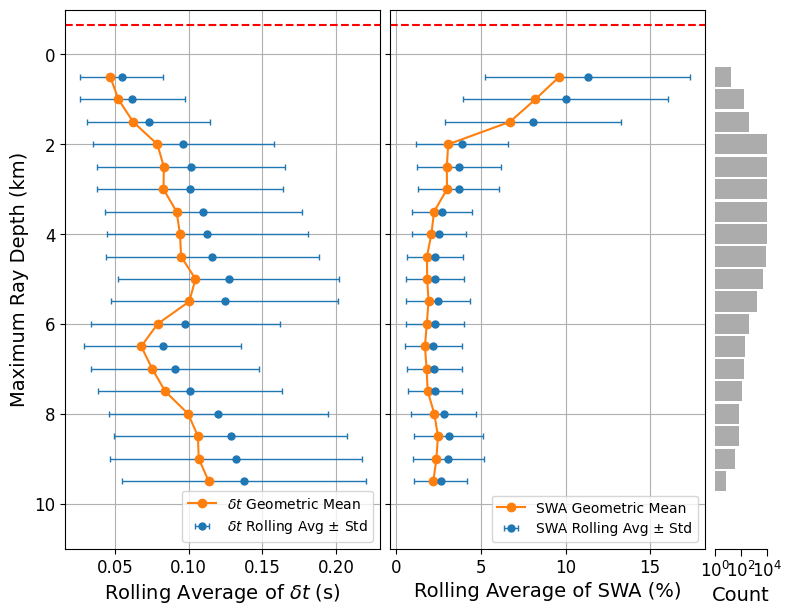

In [13]:
from scipy.stats import gmean
from matplotlib.ticker import FuncFormatter

WINDOW_WIDTH = 1.0
STEP = 0.5
MIN_DEPTH = -0.5
MAX_DEPTH = 11
SURFACE_ELEV = -0.65

LABEL_FS = 14
TICK_FS = 12
LEGEND_FS = 10


def compute_window_stats(df, value_col, window_width, step, min_depth, max_depth):
    sorted_df = df.sort_values('max_ray_depth_km').reset_index(drop=True)
    depth = sorted_df['max_ray_depth_km'].to_numpy()
    values = sorted_df[value_col].to_numpy()
    window_centers = np.arange(min_depth, max_depth + step, step)

    avg_list, std_list, geo_list, count_list = [], [], [], []

    for center in window_centers:
        left = center - window_width / 2
        right = center + window_width / 2
        in_window = (depth >= left) & (depth < right)

        if np.any(in_window):
            vals = values[in_window]
            avg_list.append(np.nanmean(vals))
            std_list.append(np.nanstd(vals))
            count_list.append(int(np.sum(in_window)))

            finite_positive = vals[np.isfinite(vals) & (vals > 0)]
            geo_list.append(np.nan if finite_positive.size == 0 else gmean(finite_positive))
        else:
            avg_list.append(np.nan)
            std_list.append(np.nan)
            geo_list.append(np.nan)
            count_list.append(0)

    return pd.DataFrame(
        {
            'center': window_centers,
            f'{value_col}_avg': avg_list,
            f'{value_col}_std': std_list,
            f'{value_col}_geo': geo_list,
            'n': count_list,
        }
    )


def style_count_axis(ax):
    ax.set_xlabel('Count', fontsize=LABEL_FS)
    ax.set_xlim(left=1, right=10000)
    ax.set_xscale('log')
    ax.yaxis.set_visible(False)
    ax.set_ylim((MAX_DEPTH, -1))

    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(True)

    sns.despine(ax=ax, left=True)
    ax.grid(False)
    ax.set_xticks([1, 100, 10000])

    def exp_format(x, _):
        if x <= 0:
            return '0'
        return rf'$10^{{{int(np.log10(x))}}}$'

    ax.xaxis.set_major_formatter(FuncFormatter(exp_format))
    ax.tick_params(axis='x', which='major', length=5, labelsize=TICK_FS)


def plot_main_axis(ax, window_df, value_col, x_label, avg_label, geo_label, legend_loc='lower right'):
    ax.errorbar(
        window_df[f'{value_col}_avg'],
        window_df['center'],
        xerr=window_df[f'{value_col}_std'],
        fmt='o',
        color='tab:blue',
        ecolor='tab:blue',
        elinewidth=1,
        capsize=2,
        markersize=5,
        label=avg_label,
    )
    ax.plot(window_df[f'{value_col}_geo'], window_df['center'], 'o-', color='tab:orange', label=geo_label)
    ax.set_xlabel(x_label, fontsize=LABEL_FS)
    ax.set_ylabel('Maximum Ray Depth (km)', fontsize=LABEL_FS)
    ax.set_ylim((MAX_DEPTH, MIN_DEPTH))
    ax.axhline(y=SURFACE_ELEV, color='red', linestyle='--')
    ax.grid(True)
    ax.legend(loc=legend_loc, fontsize=LEGEND_FS)
    ax.label_outer()

    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(True)

    ax.tick_params(axis='both', which='major', labelsize=TICK_FS)


window_tlag = compute_window_stats(splitting_data, 'tlag', WINDOW_WIDTH, STEP, MIN_DEPTH, MAX_DEPTH)
window_swa = compute_window_stats(
    splitting_data,
    'SWA_source_to_station',
    WINDOW_WIDTH,
    STEP,
    MIN_DEPTH,
    MAX_DEPTH,
)

fig = plt.figure(figsize=(10, 7))
gs = gridspec.GridSpec(1, 5, width_ratios=[1.2, 1.2, 0.2, 0.1, 0.1], wspace=0.07)

ax_dt = plt.subplot(gs[0, 0])
plot_main_axis(
    ax_dt,
    window_tlag,
    'tlag',
    r'Rolling Average of $\delta t$ (s)',
    r'$\delta t$ Rolling Avg ± Std',
    r'$\delta t$ Geometric Mean',
)

ax_swa = plt.subplot(gs[0, 1], sharey=ax_dt)
plot_main_axis(
    ax_swa,
    window_swa,
    'SWA_source_to_station',
    'Rolling Average of SWA (%)',
    'SWA Rolling Avg ± Std',
    'SWA Geometric Mean',
)

ax_swa_counts = plt.subplot(gs[0, 2], sharey=ax_dt)
ax_swa_counts.barh(
    window_swa['center'],
    np.where(window_swa['n'] >= 1, window_swa['n'].astype(float), np.nan),
    height=STEP * 0.9,
    color='gray',
    alpha=0.65,
)
style_count_axis(ax_swa_counts)

for ax in [ax_dt, ax_swa, ax_swa_counts]:
    ax.tick_params(axis='y', labelsize=TICK_FS)

plt.savefig('./Plots/Figure_7.png', dpi=150, bbox_inches='tight')
